<a href="https://colab.research.google.com/github/fireninja384/Linear-Regression-Project/blob/main/Linear_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving data_description.txt to data_description.txt
Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
User uploaded file "data_description.txt" with length 13370 bytes
User uploaded file "sample_submission.csv" with length 31939 bytes
User uploaded file "test.csv" with length 451405 bytes
User uploaded file "train.csv" with length 460676 bytes


1460
Starting theta0, theta1, theta2: 50.0 5.0 5.0
Starting learning rate alpha: 1e-08
Starting cost J: 575.4419037897416
Final theta0, theta1, theta2: 50.0000373217314 4.999932512768621 4.999778932940732
Final cost J: 575.4364274632458


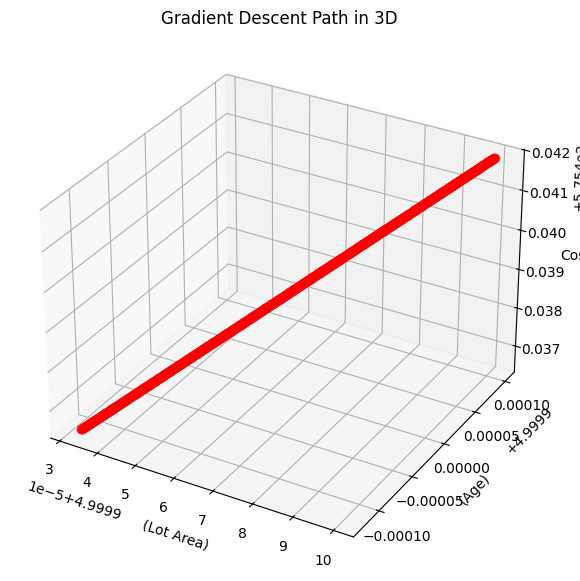

In [ ]:
#https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data


df = pd.read_csv("train.csv");

x = df["LotArea"].to_numpy(float)     # Lot Area
y = 2025 - df["YearBuilt"].to_numpy(float)     # Years Old
z = df["SalePrice"].to_numpy(float) #Price of the house

# Normalize features
x = (x - np.mean(x)) / np.std(x)
z = (z - np.mean(z)) / np.std(z)


m = x.shape[0]
print(m)



theta0 = 50.0
theta1 = 5.0
theta2 = 5.0
alpha = 0.00000001
epochs = 1000

y_hat = theta0 + (theta1*x) + (theta2*z)         # fill with a vectorized expression using theta0, theta1, x
errors = y_hat - y

J = np.dot(errors, errors) / (2*m) # same as np.dot(errors, errors)

print("Starting theta0, theta1, theta2:", theta0, theta1, theta2)
print("Starting learning rate alpha:", alpha)
print("Starting cost J:", J)

J_hist = []

theta1_history = []
theta2_history = []


for _ in range(epochs):

  y_hat = theta0 + (theta1*x) + (theta2*z)         # fill with a vectorized expression using theta0, theta1, x
  errors = y_hat - y

  grad_theta0 = (1/m) * np.sum(errors)
  grad_theta1 =  (1/m) * np.sum(errors * x)
  grad_theta2 =  (1/m) * np.sum(errors * z)

  theta0 = theta0 - alpha * grad_theta0
  theta1 = theta1 - alpha * grad_theta1
  theta2 = theta2 - alpha * grad_theta2

  theta1_history.append(theta1)
  theta2_history.append(theta2)

  J = np.dot(errors, errors) / (2*m)
  J_hist.append(J)

print("Final theta0, theta1, theta2:", theta0, theta1, theta2)
print("Final cost J:", J_hist[-1])

# 4) Plot cost vs epoch

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(theta1_history, theta2_history, J_hist, color='red', marker='o', alpha=0.6)
ax.set_xlabel("(Lot Area)")
ax.set_ylabel("(Age)")
ax.set_zlabel("Cost")
ax.set_title("Gradient Descent Path in 3D")
plt.show()